# Vertical profiles — ICON *LessOzone* experiment

Zonal-mean latitude–height difference sections (our simulation − slab control).

**Plots produced here**
1. Vertical temperature profile (`ta`)
2. Vertical profile of eastward (zonal) wind (`ua`)

**Memory note.** The 3D files are large (~18 GB / ~14 GB across all variables).
We never load a whole file. Each plot:
  1. restricts to the selected year window (lazily, on disk),
  2. loads only the *one* variable it needs (~0.2 GB after windowing),
  3. collapses the big `ncells` dimension into latitude bands.
So peak memory stays around a few hundred MB.

The zonal mean auto-detects whether the file is on the ICON unstructured grid
(`ncells`) or a regular lat/lon mesh, so the notebook runs before *and* after a
CDO regrid.


In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats

# Larger fonts everywhere (default labels were too small)
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.dpi": 110,
})

## Open datasets (lazy — nothing loaded into RAM yet)

In [2]:


# open_dataset is lazy: it reads metadata only. Data is pulled in later,
# one windowed variable at a time, inside zonal_mean_var().
data_slabctr = xr.open_dataset(f"slabctr_3D_REGRID_2000-2035.nc")        # slab control
data         = xr.open_dataset(f"LessOzone_Real_3D_2000-2035.nc")  # our simulation

# Grid file (only needed if the 3D files are unstructured and lack their own clat).
try:
    grid = xr.open_dataset(f"icon_grid_G.nc")
except FileNotFoundError:
    grid = None


def to_datetime(ds):
    """Convert the YYYYMMDD float time axis into a proper datetime index."""
    strs = [str(int(d)) for d in ds["time"].values]
    iso  = [f"{s[:4]}-{s[4:6]}-{s[6:]}" for s in strs]
    return ds.assign_coords(time=pd.to_datetime(iso))


data_slabctr = to_datetime(data_slabctr)
data         = to_datetime(data)

# Control run carries an extra first month (Jan 2000) the simulation lacks.
data_slabctr = data_slabctr.isel(time=slice(1, None))

print("dims:", dict(data.sizes))

dims: {'ncells': 20480, 'vertices': 3, 'height': 47, 'bnds': 2, 'time': 420}


## Year window for temporal means



In [3]:
MODE    = "last5"      # "last5" | "first5" | "all"
N_YEARS = 5

years = np.unique(data["time"].dt.year.values)
if MODE == "last5":
    sel_years = years[-N_YEARS:]
elif MODE == "first5":
    sel_years = years[:N_YEARS]
elif MODE == "all":
    sel_years = years
else:
    raise ValueError(f"Unknown MODE: {MODE!r}")

period = f"{int(sel_years.min())}-{int(sel_years.max())}"
print(f"MODE={MODE!r} -> averaging {len(sel_years)} years ({period})")


def in_window(ds):
    """Restrict a dataset to the selected years (still lazy)."""
    return ds.sel(time=ds["time"].dt.year.isin(sel_years))

MODE='last5' -> averaging 5 years (2031-2035)


## Zonal mean — auto-detects the grid, loads one variable at a time

* **Regular grid** (a `lon` dimension exists): plain `mean(dim="lon")`.
* **Unstructured grid** (`ncells`): bin cells into latitude bands and average
  within each band. Latitudes come from the file's own `clat` if present,
  otherwise from the grid file; radians are converted to degrees automatically.

`zonal_mean_var(ds, var)` loads only `ds[var]` — never the whole file — so
memory stays small even though each file is many GB.

`N_LAT_BINS` controls the resolution of the binned latitude axis.

In [4]:
N_LAT_BINS = 90   # ~2° bands; used for the unstructured path


def _cell_lats_deg(ds):
    """Per-cell latitudes in DEGREES. Looks in the dataset, then the grid file.
    Only accepts a latitude that actually lives on the 'ncells' dimension."""
    src = None
    for name in ("clat", "lat"):
        if name in ds.coords or name in ds.variables:
            cand = ds[name]
            if "ncells" in cand.dims:
                src = cand
                break
    if src is None and grid is not None and "clat" in grid:
        src = grid["clat"]
    if src is None:
        raise KeyError("No per-cell 'clat'/'lat' found in the file or the grid file.")
    vals = np.asarray(src.values)
    if np.nanmax(np.abs(vals)) <= (np.pi + 0.01):   # radians -> degrees
        vals = np.rad2deg(vals)
    return vals


_bin_edges = np.linspace(-90, 90, N_LAT_BINS + 1)
_bin_ctr   = 0.5 * (_bin_edges[:-1] + _bin_edges[1:])


def zonal_mean_var(ds, var):
    """Zonal mean for ONE variable. Detects the grid of *this* dataset
    (the control and the simulation may differ): unstructured (ncells) ->
    latitude binning; regular lat/lon -> mean over lon. Loads only this
    (windowed) variable into memory."""
    da = ds[var]

    if "ncells" in da.dims:
        lat_cells   = _cell_lats_deg(ds)
        bin_idx     = np.clip(np.digitize(lat_cells, _bin_edges) - 1, 0, N_LAT_BINS - 1)
        lat_of_cell = _bin_ctr[bin_idx]
        da = da.load()                                      # only this var -> RAM
        da = da.drop_vars([c for c in ("lat", "lon") if c in da.coords],
                          errors="ignore")
        da = da.assign_coords(lat_band=("ncells", lat_of_cell))
        out = (da.groupby("lat_band").mean(dim="ncells")
                 .rename({"lat_band": "lat"}))
    elif "lon" in da.dims:
        out = da.mean(dim="lon").load()
    else:
        raise ValueError(f"{var!r} has dims {da.dims} - neither 'ncells' nor 'lon'.")

    return out.transpose("time", "height", "lat", ...)


def _grid_kind(ds):
    return ("unstructured (ncells)" if "ncells" in ds.sizes
            else "regular lat/lon" if "lon" in ds.sizes else "unknown")


print("simulation :", _grid_kind(data))
print("control    :", _grid_kind(data_slabctr))

simulation : unstructured (ncells)
control    : regular lat/lon


## Section helper

In [5]:
MONTHS = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]


def profile(var, month, *, title, cbar_label, cmap, vmax=None, savename=None):
    """Latitude–height difference section for one variable and calendar month,
    averaged over the windowed years, with non-significant areas hatched.
    `vmax` fixes a symmetric diverging scale; if None it is taken from the data."""
    # Window first (lazy), then load only this variable's zonal mean.
    sim  = zonal_mean_var(in_window(data),         var)
    ctrl = zonal_mean_var(in_window(data_slabctr), var)

    sub_sim  = sim.sel(time=sim.time.dt.month == month).sortby("lat")
    sub_ctrl = ctrl.sel(time=ctrl.time.dt.month == month).sortby("lat")

    # The two runs may be on different latitude axes (e.g. a binned unstructured
    # simulation vs. a regular-grid control). Put the control onto the
    # simulation's lat axis before differencing. (No-op if already identical.)
    if not np.array_equal(sub_ctrl["lat"].values, sub_sim["lat"].values):
        sub_ctrl = sub_ctrl.interp(lat=sub_sim["lat"],
                                   kwargs={"fill_value": "extrapolate"})

    field = sub_sim.mean("time") - sub_ctrl.mean("time")        # (height, lat)

    # t-test across the windowed years (time is axis 0) -> p shape (height, lat)
    _, p = stats.ttest_ind(sub_sim.values, sub_ctrl.values, axis=0)
    not_significant = p >= 0.05
    print(f"  t-test: {sub_sim.sizes['time']} vs {sub_ctrl.sizes['time']} years")

    if vmax is None:
        vmax = float(np.nanmax(np.abs(field.values)))
    # TwoSlopeNorm needs vmin < 0 < vmax. Guard against an all-zero or
    # one-sided field (e.g. a difference that never crosses zero), which
    # would otherwise raise "vmin, vcenter, vmax must be ascending".
    if not np.isfinite(vmax) or vmax == 0:
        norm = None  # let pcolormesh autoscale
    else:
        norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(11, 6))
    pcm = ax.pcolormesh(field.lat, field.height, field,
                        shading="auto", cmap=cmap, norm=norm)
    ax.contourf(field.lat, field.height, not_significant.astype(float),
                levels=[0.5, 1.5], hatches=["////"], colors="none")

    cb = fig.colorbar(pcm, ax=ax)
    cb.set_label(cbar_label)
    ax.set_xlabel("Latitude [°N]")
    ax.set_ylabel("Model level")
    ax.set_title(title, pad=10)
    ax.invert_yaxis()      # level 1 (top of atmosphere) at the top

    fig.tight_layout()
    if savename:
        fig.savefig(savename, dpi=300, bbox_inches="tight")
        print("saved", savename)
    plt.show()

## Plot 1 — Vertical temperature profile

Zonal- and time-mean temperature difference. Set `MONTH`.

  t-test: 4 vs 4 years
saved profile_ta_August_2031-2035.png


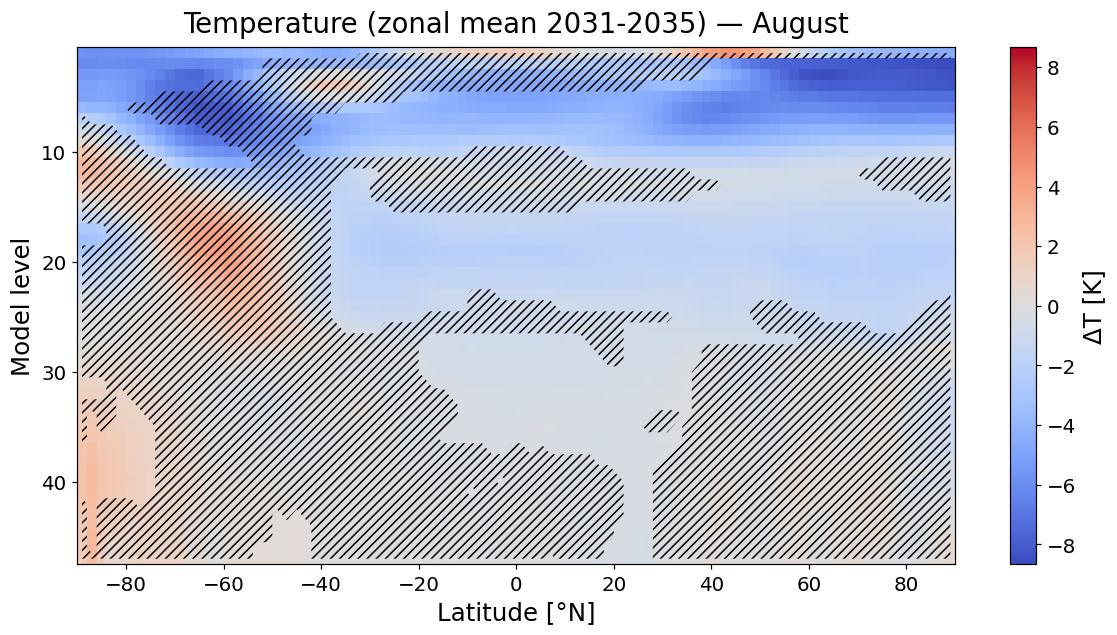

In [6]:
MONTH = 8     # 1 = Jan … 12 = Dec

profile(
    "ta", MONTH,
    title=f"Temperature (zonal mean {period}) — {MONTHS[MONTH-1]}",
    cbar_label="ΔT [K]",
    cmap="coolwarm",
    savename=f"profile_ta_{MONTHS[MONTH-1]}_{period}.png",
)

## Plot 2 — Vertical profile of zonal wind

Zonal- and time-mean eastward-wind difference. Set `MONTH` (a winter month is
often most informative for jet changes).

  t-test: 4 vs 4 years
saved profile_ua_August_2031-2035.png


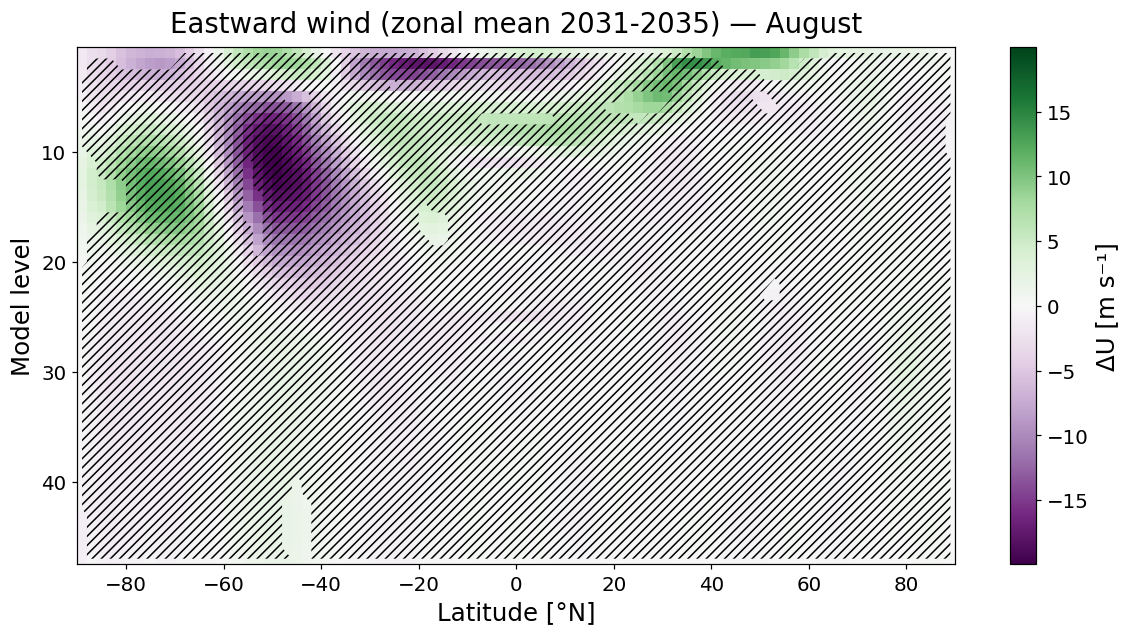

In [7]:
MONTH = 8     # 1 = Jan … 12 = Dec

profile(
    "ua", MONTH,
    title=f"Eastward wind (zonal mean {period}) — {MONTHS[MONTH-1]}",
    cbar_label="ΔU [m s⁻¹]",
    cmap="PRGn",
    savename=f"profile_ua_{MONTHS[MONTH-1]}_{period}.png",
)

## Plot 3 — Relative humidity profile

Stratospheric/tropospheric moisture response.

  t-test: 4 vs 4 years
saved profile_hur_August_2031-2035.png


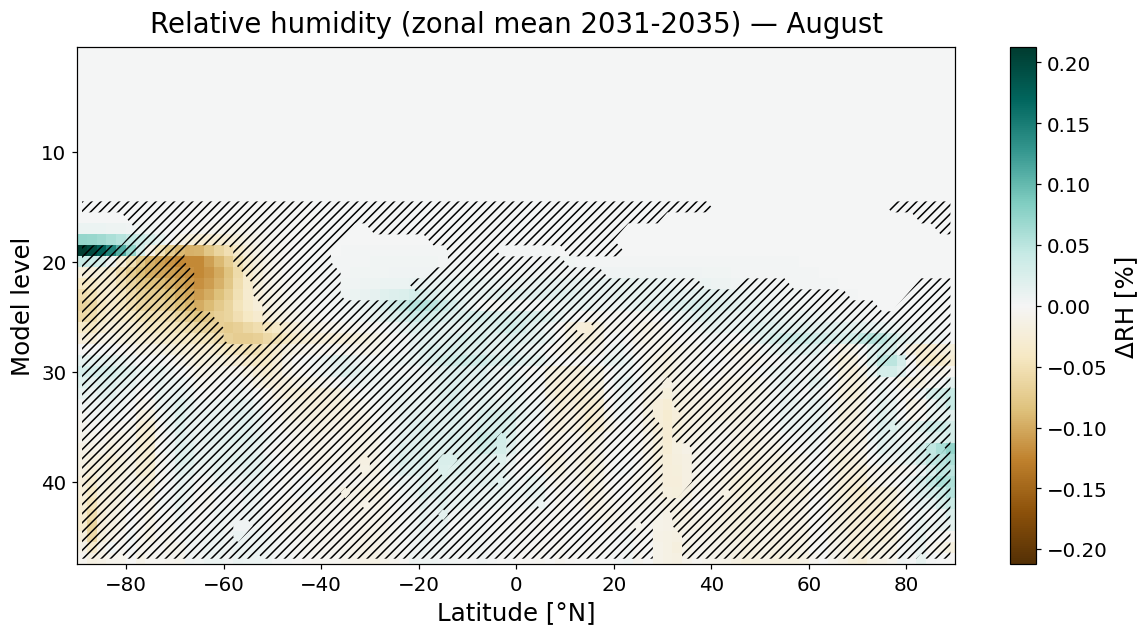

In [ ]:
MONTH = 8 
# 1 = Jan … 12 = Dec

profile(
    "hur", MONTH,
    title=f"Relative humidity (zonal mean {period}) — {MONTHS[MONTH-1]}",
    cbar_label="ΔRH [%]",
    cmap="BrBG",
    savename=f"profile_hur_{MONTHS[MONTH-1]}_{period}.png",
)

## Plot 4 — Specific humidity profile

Absolute water-vapour change.

  t-test: 4 vs 4 years
saved profile_hus_August_2031-2035.png


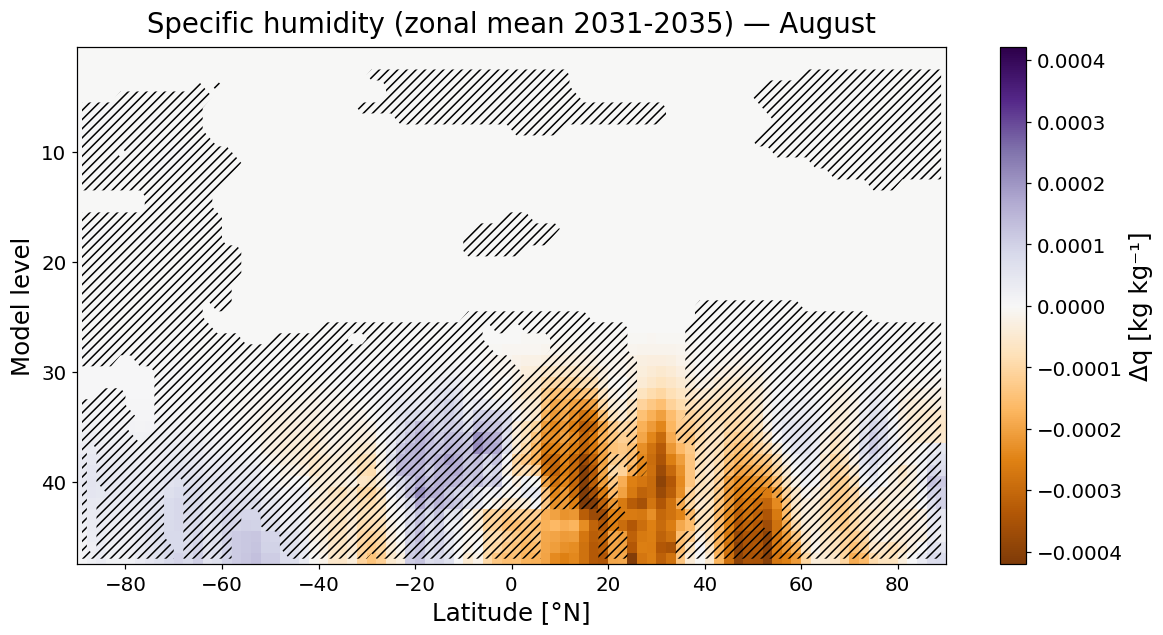

In [9]:
MONTH = 8     # 1 = Jan … 12 = Dec

profile(
    "hus", MONTH,
    title=f"Specific humidity (zonal mean {period}) — {MONTHS[MONTH-1]}",
    cbar_label="Δq [kg kg⁻¹]",
    cmap="PuOr",
    savename=f"profile_hus_{MONTHS[MONTH-1]}_{period}.png",
)

## Plot 5 — Meridional wind profile

Circulation-cell (Hadley / Brewer–Dobson) shifts.

  t-test: 4 vs 4 years
saved profile_va_August_2031-2035.png


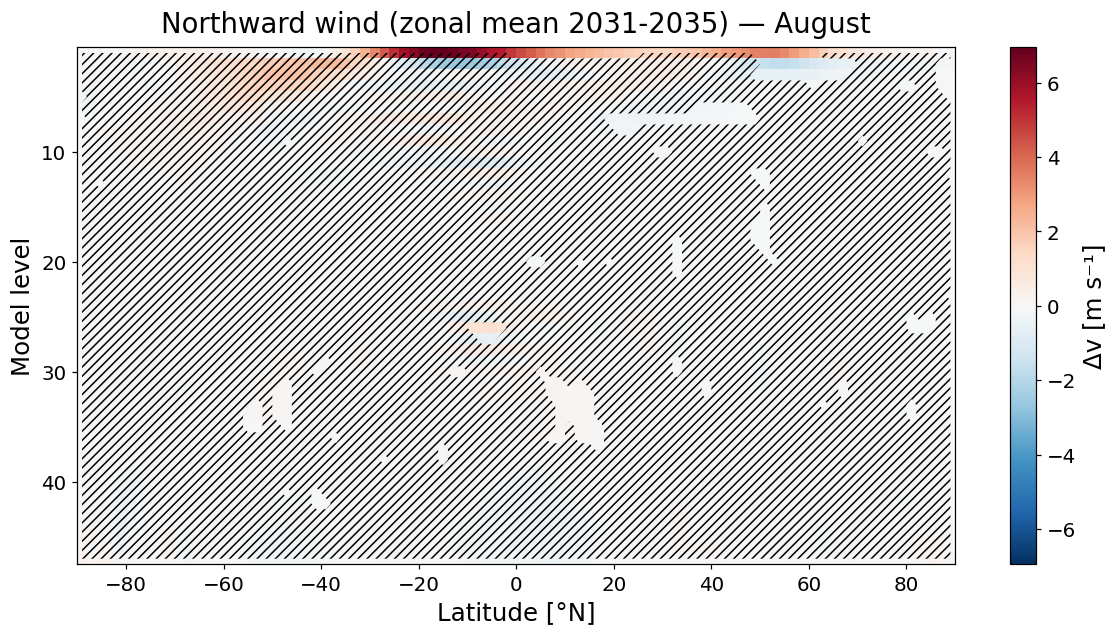

In [10]:
MONTH = 8     # 1 = Jan … 12 = Dec

profile(
    "va", MONTH,
    title=f"Northward wind (zonal mean {period}) — {MONTHS[MONTH-1]}",
    cbar_label="Δv [m s⁻¹]",
    cmap="RdBu_r",
    savename=f"profile_va_{MONTHS[MONTH-1]}_{period}.png",
)

## Plot 6 — Vertical velocity profile

Pressure vertical velocity (ω). Positive = downwelling. Upwelling / downwelling changes tied to the residual circulation.

  t-test: 4 vs 4 years
saved profile_wap_August_2031-2035.png


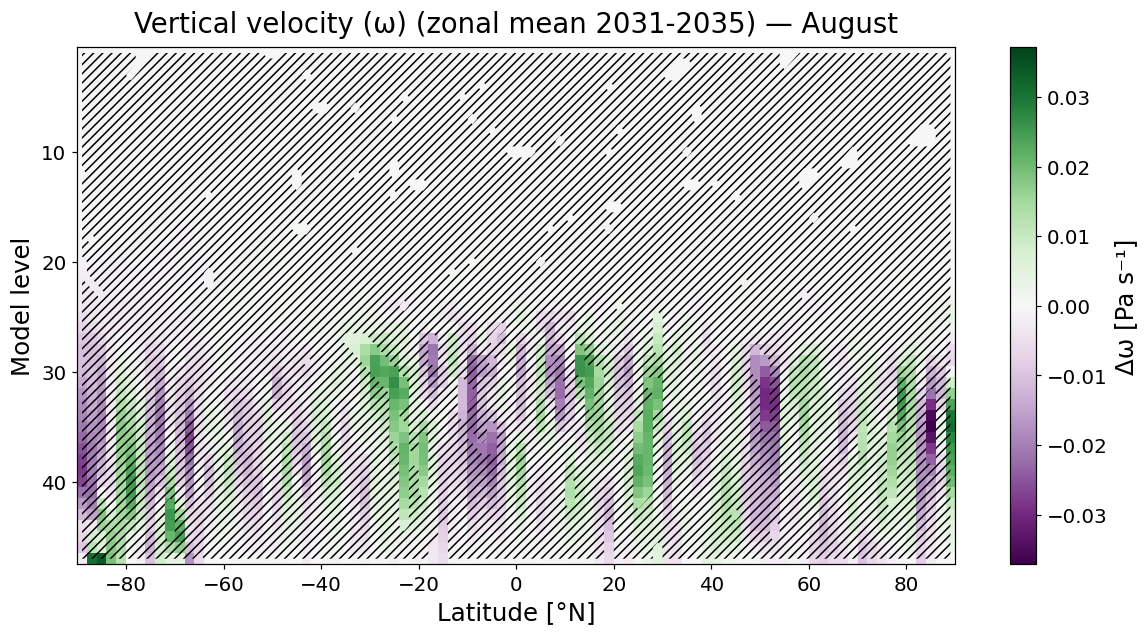

In [11]:
MONTH = 8     # 1 = Jan … 12 = Dec

profile(
    "wap", MONTH,
    title=f"Vertical velocity (ω) (zonal mean {period}) — {MONTHS[MONTH-1]}",
    cbar_label="Δω [Pa s⁻¹]",
    cmap="PRGn",
    savename=f"profile_wap_{MONTHS[MONTH-1]}_{period}.png",
)

## Plot 7 — Cloud fraction profile

Where clouds form shifts with the thermal structure.

  t-test: 4 vs 4 years
saved profile_cl_August_2031-2035.png


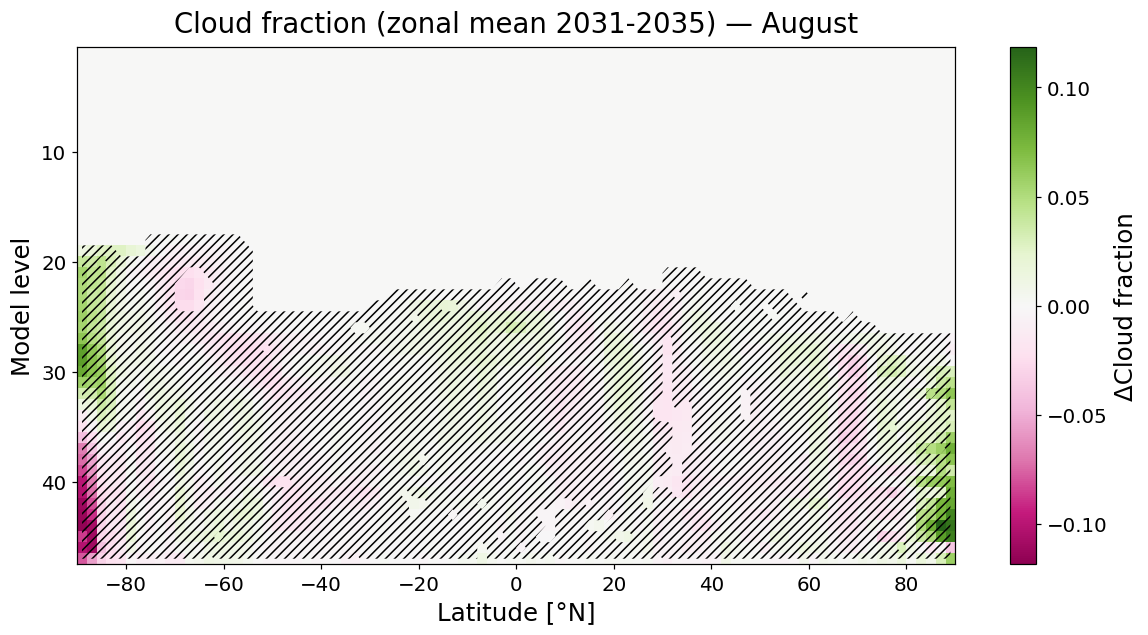

In [12]:
MONTH = 8     # 1 = Jan … 12 = Dec

profile(
    "cl", MONTH,
    title=f"Cloud fraction (zonal mean {period}) — {MONTHS[MONTH-1]}",
    cbar_label="ΔCloud fraction",
    cmap="PiYG",
    savename=f"profile_cl_{MONTHS[MONTH-1]}_{period}.png",
)

## Plot 8 — Density profile

Air-density change — a direct fingerprint of thermal expansion / contraction from the temperature response.

  t-test: 4 vs 4 years
saved profile_rho_August_2031-2035.png


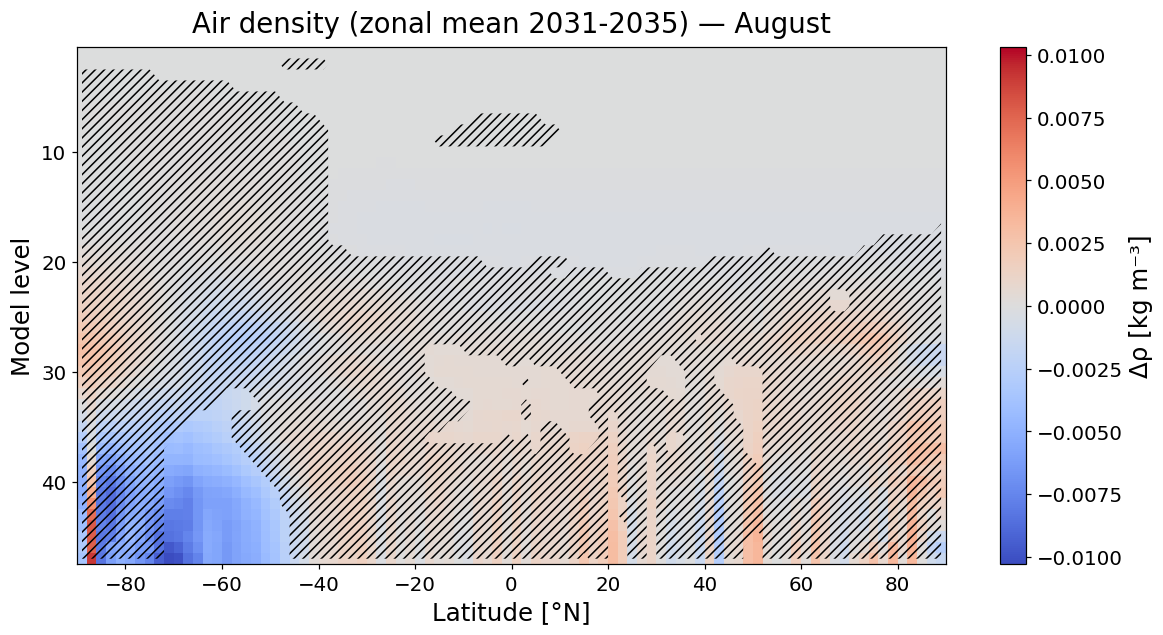

In [13]:
MONTH = 8     # 1 = Jan … 12 = Dec

profile(
    "rho", MONTH,
    title=f"Air density (zonal mean {period}) — {MONTHS[MONTH-1]}",
    cbar_label="Δρ [kg m⁻³]",
    cmap="coolwarm",
    savename=f"profile_rho_{MONTHS[MONTH-1]}_{period}.png",
)